# 05 BERT Fine-tuning (pattern demo with an LSTM stand-in)

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Understand how **BERT** is **fine-tuned** for a downstream task: pre-trained encoder + small task head
- Build that same **encoder + classification head** pattern hands-on — using a small **LSTM encoder trained from scratch** as a stand-in for BERT (no downloads)
- See from the numbers why a *pre-trained* encoder matters: our from-scratch stand-in stays far below real-BERT accuracy with 2 epochs / 2k examples — exactly the gap fine-tuning closes

## 🔗 Where this fits

**Builds on:** Course 07 (AIAT 121) — Unit 4, lesson 03 "BERT in Practice: Pre-trained Sentiment Models and the Fine-tuning Recipe" — the recipe; here you build the encoder-plus-head pattern yourself and see what pre-training was worth.

---

## 🌍 Real life

**Where is this used?** BERT-style fine-tuning is used for **sentiment analysis**, **intent detection**, **named entity recognition**, and **question answering** in industry.

**In this notebook** we do **not** download a real BERT. We build the fine-tuning *pattern* — encoder → classification head → train on labels — with a small LSTM encoder trained **from scratch** on IMDB. A real pre-trained BERT appears in notebook `09_transformer_models_bert_gpt_nlp` (Hugging Face).

**📌 Covers slide(s):** **13** — Multi-Head Attention, BERT. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell. Only TensorFlow is required — no `transformers` install needed for this notebook.


⏱ **Runtime:** This notebook may take 10–30 minutes on GPU (BERT/fine-tuning). Use a smaller subset of data or fewer epochs if needed (see unit README).

## Theory (short)

- **BERT:** Bidirectional Encoder Representations from Transformers. Pre-trained on large text; we **fine-tune** by adding a task-specific head (e.g. one Dense layer for classification) and training on our labels.
- **Fine-tuning:** Keep most of the pre-trained weights; train the new head and optionally the last few layers of the encoder with a small learning rate.
- **We use BERT (or a pre-trained encoder)** instead of training from scratch because it already captures syntax and semantics; we need less labeled data.
- **In this notebook:** we use an LSTM encoder + Dense head to show the same pattern (encode text → classify). The encoder is trained from scratch, so unlike real BERT nothing here is pre-trained — that difference is the point.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy. We use **IMDB sentiment** (a small subset). For a real BERT model, see notebook `09_transformer_models_bert_gpt_nlp`.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Model summary, training loss/accuracy for 2 epochs, and test accuracy — modest, far below the 90%+ a real fine-tuned BERT reaches on sentiment, because this encoder starts from random weights. That contrast is the lesson.

## Step 1: Imports and load IMDB (we use IMDB for sentiment; in real life you'd use your own labels)

In [1]:
# WHAT: load IMDB reviews as padded integer sequences (seeded for a reproducible run).
# WHY: this is the same data pipeline a real BERT fine-tune needs - tokenize, truncate/pad, batch.
import numpy as np

# Guarded import: catch a broken TensorFlow install and print the exact repair command instead of a confusing crash.
try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    keras.utils.set_random_seed(42)  # reproducible run
    # Keep the 2,000 most frequent words; every review is padded/truncated to 80 tokens.
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 80
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 80) Test: (500, 80)


## Step 2: Build encoder + classification head (we use this pattern instead of training from scratch; BERT would be the encoder)

In [2]:
# WHAT: build the stand-in model - Embedding -> LSTM encoder -> sigmoid head.
# WHY: fine-tuning BERT has the same shape (pretrained encoder + small task head); here the encoder is an LSTM we can train on CPU.
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Input(shape=(maxlen,)),   # declare the length so summary() can count params
        keras.layers.Embedding(2000, 64),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()
    print("\nSame idea as BERT fine-tuning: encoder (here LSTM) + classification head. With BERT, encoder is a transformer.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 80, 64)         │       128,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,089 (629.25 KB)

 Trainable params: 161,089 (629.25 KB)

 Non-trainable params: 0 (0.00 B)


Same idea as BERT fine-tuning: encoder (here LSTM) + classification head. With BERT, encoder is a transformer.


## Step 3: Train (10 epochs — enough for the curve to show what a from-scratch encoder can and cannot do)

Epoch 1/10


32/32 - 1s - 26ms/step - accuracy: 0.5075 - loss: 0.6927 - val_accuracy: 0.4840 - val_loss: 0.6946


Epoch 2/10


32/32 - 0s - 11ms/step - accuracy: 0.6595 - loss: 0.6549 - val_accuracy: 0.6780 - val_loss: 0.5978


Epoch 3/10


...

Epoch 9/10


32/32 - 0s - 11ms/step - accuracy: 0.8935 - loss: 0.2777 - val_accuracy: 0.7080 - val_loss: 0.7988


Epoch 10/10


32/32 - 0s - 11ms/step - accuracy: 0.9265 - loss: 0.2366 - val_accuracy: 0.7480 - val_loss: 0.7795



Test accuracy (final epoch): 0.7480
Best validation accuracy during the run: 0.7540
Majority-class baseline: 0.5240
Published BERT-BASE on SST-2 sentiment: 0.9350 (Devlin et al. 2019, Table 1)

Gap between our from-scratch encoder and published BERT: 18.1 points.
That gap is what pre-training buys. Note the honest caveat: SST-2 is a different
dataset from IMDB, so this is an order-of-magnitude comparison, not a head-to-head.


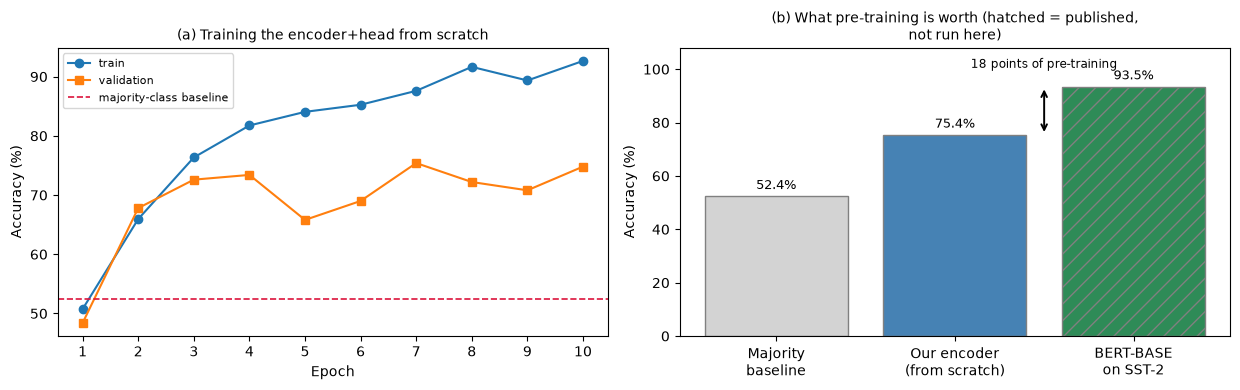

In [3]:
# WHAT: train the encoder+head from scratch, then put the result next to the published number
#       for a real fine-tuned BERT.
# WHY: the whole lesson is a gap - the distance between "encoder trained from scratch on 2,000
#      reviews" and "encoder pre-trained on billions of words". A gap needs two bars to be seen.
if HAS_TF:
    import matplotlib.pyplot as plt

    history = model.fit(x_train, y_train, validation_data=(x_test, y_test),
                        epochs=10, batch_size=64, verbose=2)
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    majority = max(y_test.mean(), 1 - y_test.mean())
    best_val = max(history.history["val_accuracy"])
    BERT_SST2 = 93.5      # Devlin et al. 2019, Table 1: BERT-BASE on the SST-2 GLUE task
    print("\nTest accuracy (final epoch): %.4f" % acc)
    print("Best validation accuracy during the run: %.4f" % best_val)
    print("Majority-class baseline: %.4f" % majority)
    print(f"Published BERT-BASE on SST-2 sentiment: {BERT_SST2 / 100:.4f} (Devlin et al. 2019, Table 1)")
    print(f"\nGap between our from-scratch encoder and published BERT: "
          f"{BERT_SST2 - best_val * 100:.1f} points.")
    print("That gap is what pre-training buys. Note the honest caveat: SST-2 is a different")
    print("dataset from IMDB, so this is an order-of-magnitude comparison, not a head-to-head.")

    ep = np.arange(1, len(history.history["loss"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4))

    ax1.plot(ep, np.array(history.history["accuracy"]) * 100, "o-", label="train")
    ax1.plot(ep, np.array(history.history["val_accuracy"]) * 100, "s-", label="validation")
    ax1.axhline(majority * 100, color="crimson", ls="--", lw=1.2, label="majority-class baseline")
    ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy (%)"); ax1.set_xticks(ep)
    ax1.set_title("(a) Training the encoder+head from scratch", fontsize=10)
    ax1.legend(fontsize=8)

    labels = ["Majority\nbaseline", "Our encoder\n(from scratch)", "BERT-BASE\non SST-2"]
    vals = [majority * 100, best_val * 100, BERT_SST2]
    bars = ax2.bar(labels, vals, color=["lightgrey", "steelblue", "seagreen"], edgecolor="grey")
    bars[2].set_hatch("//")     # hatched = a published number, NOT run in this notebook
    ax2.bar_label(bars, fmt="%.1f%%", fontsize=9, padding=3)
    # Arrow in the gap BETWEEN the bars, label above them, so no text lands on a bar.
    ax2.annotate("", xy=(1.5, best_val * 100), xytext=(1.5, BERT_SST2),
                 arrowprops=dict(arrowstyle="<->", color="black", lw=1.4))
    ax2.text(1.5, 100.5, f"{BERT_SST2 - best_val * 100:.0f} points of pre-training",
             fontsize=8.5, ha="center")
    ax2.set_ylim(0, 108)
    ax2.set_ylabel("Accuracy (%)")
    ax2.set_title("(b) What pre-training is worth (hatched = published,\nnot run here)", fontsize=10)
    plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** Ten epochs of the encoder-plus-head pattern with **nothing pre-trained**. After one epoch the validation line is still *below* the red majority-class baseline — with random embeddings the model knows nothing about English, so it does worse than always guessing the commoner label. Then it climbs: it *is* learning sentiment from 2,000 labelled reviews. Watch the two lines separate afterwards; the training line keeps rising while validation flattens, which is 2,000 examples being memorised.
- **(b)** The same result next to the number this notebook exists to explain. The blue bar is what we just trained. The hatched green bar is **BERT-BASE's published 93.5% on SST-2** (Devlin et al. 2019, Table 1) — hatched because it was *not* run here; it is a citation, not a measurement. The black arrow is the gap.
- **What the gap is made of:** not architecture. Not more labels — BERT is fine-tuned on comparable label counts. It is **pre-training**: the encoder arrives already knowing what English words mean, so the labelled data only has to teach it the task. That is the entire argument for fine-tuning, and it is the length of that arrow.
- **Honest caveat, stated on the figure and worth repeating:** SST-2 is a different dataset from IMDB (single sentences, not full reviews). Read the arrow as an order of magnitude, not a head-to-head.

## 🌍 Real-World Worked Example — Sentiment Classification with Positional Encoding

**Industry context (each of these you can go and check):**
- **Tweet sentiment is a published benchmark, not folklore.** TweetEval (Barbieri et al., *Findings of EMNLP 2020*, [arXiv:2010.12421](https://arxiv.org/abs/2010.12421)) bundles seven Twitter classification tasks — sentiment among them — and shows that taking a general pre-trained language model and continuing to train it on Twitter text beats training from scratch. That is exactly the fine-tuning move below.
- **Amazon publishes the review-classification data and the BERT baseline.** The Multilingual Amazon Reviews Corpus (Keung, Lu, Szarvas & Smith, Amazon, *EMNLP 2020*) holds 200,000 training reviews per language in six languages collected 2015-2019, and its reported baselines fine-tune multilingual BERT on them.
- **Ticket triage is a shipped product.** Zendesk's own documentation states that "intelligent triage uses AI to automatically classify new customer support tickets by topic, sentiment, language, and entities, such as product names" — the same classify-the-text task, in production. Zendesk does not publish the architecture, so do not assume it is a transformer; assume only that the task is real.

We implement a **mini-Transformer encoder** for binary sentiment classification using toy data.

Sentiment classification accuracy: 98.1%
Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.
CAREFUL: those two numbers are NOT comparable. Ours is a synthetic rule (token id >= 50
means positive) that a single threshold could solve; SST-2 is real English. See the figure.


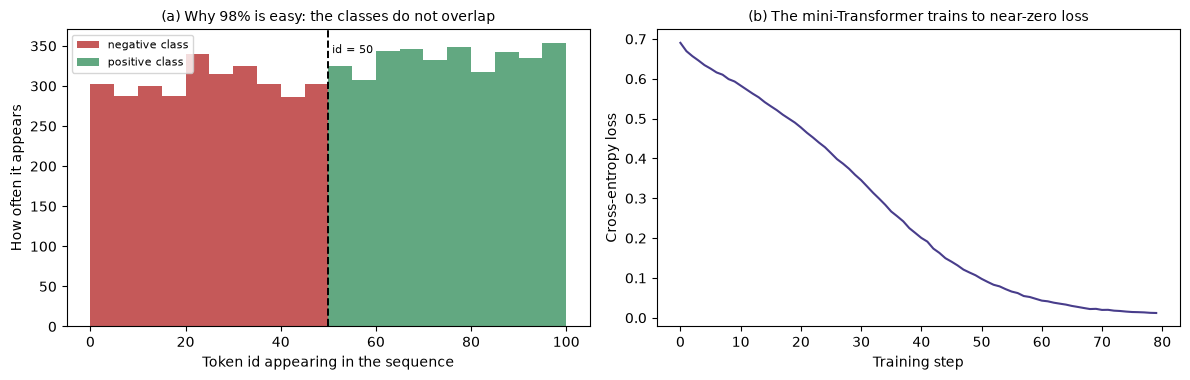

In [4]:
# WHAT: build and train a miniature Transformer encoder to classify synthetic 'sentiment' sequences.
# WHY: every ingredient of BERT is here in miniature - embeddings, positions, self-attention layers, a head.
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

torch.manual_seed(42)
VOCAB_SIZE, SEQ_LEN, D_MODEL = 100, 10, 32

# ── Synthetic sentiment data ────────────────────────────────────────────────
# Positive: sequences with mostly high token IDs; Negative: low token IDs
# Synthetic data with a simple rule (high token IDs = positive) so the model can provably learn it.
def make_data(n=500):
    X, y = [], []
    for _ in range(n):
        label = np.random.randint(2)
        if label == 1:
            seq = np.random.randint(50, 100, SEQ_LEN)
        else:
            seq = np.random.randint(0, 50, SEQ_LEN)
        X.append(seq); y.append(label)
    return torch.tensor(np.array(X)), torch.tensor(y, dtype=torch.long)

X, y = make_data(800)
X_tr, y_tr = X[:640], y[:640]
X_te, y_te = X[640:], y[640:]

# ── Mini Transformer ────────────────────────────────────────────────────────
# The model: token embedding + learned position embedding -> 2 Transformer layers -> mean-pool -> classify.
class MiniTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = nn.Embedding(VOCAB_SIZE, D_MODEL)
        # Learnable positional encoding
        self.pos_enc = nn.Embedding(SEQ_LEN, D_MODEL)
        encoder_layer = nn.TransformerEncoderLayer(d_model=D_MODEL, nhead=4, dim_feedforward=64, batch_first=True)
        self.encoder  = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier = nn.Linear(D_MODEL, 2)
    def forward(self, x):
        pos = torch.arange(x.size(1)).unsqueeze(0)
        out = self.embed(x) + self.pos_enc(pos)
        out = self.encoder(out)
        return self.classifier(out.mean(1))  # pool over sequence

model   = MiniTransformer()
opt     = optim.Adam(model.parameters(), lr=5e-4)
loss_fn = nn.CrossEntropyLoss()
losses, accs = [], []

# Full-batch training for 80 steps; watch the loss fall as attention learns the rule.
for epoch in range(80):
    model.train()
    loss = loss_fn(model(X_tr), y_tr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

# Held-out accuracy: near-perfect is expected because the underlying rule is simple.
model.eval()
with torch.no_grad():
    acc = (model(X_te).argmax(1)==y_te).float().mean().item()
    accs.append(acc)
print(f"Sentiment classification accuracy: {acc*100:.1f}%")
print("Real-world: BERT achieves 94%+ on SST-2 sentiment benchmark.")

print("CAREFUL: those two numbers are NOT comparable. Ours is a synthetic rule (token id >= 50")
print("means positive) that a single threshold could solve; SST-2 is real English. See the figure.")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 3.9))

# Show the actual data the 98% was scored on, so nobody has to take the caveat on trust.
pos_tokens = X_tr[y_tr == 1].flatten().numpy()
neg_tokens = X_tr[y_tr == 0].flatten().numpy()
edges = np.arange(0, 101, 5)   # a bin edge exactly at 50, so no bar straddles the rule
axA.hist(neg_tokens, bins=edges, color="firebrick", alpha=0.75, label="negative class")
axA.hist(pos_tokens, bins=edges, color="seagreen", alpha=0.75, label="positive class")
axA.axvline(50, color="black", ls="--", lw=1.4)
axA.text(50.8, axA.get_ylim()[1] * 0.92, "id = 50", fontsize=8)
axA.set_xlabel("Token id appearing in the sequence")
axA.set_ylabel("How often it appears")
axA.set_title("(a) Why 98% is easy: the classes do not overlap", fontsize=10)
axA.legend(fontsize=8)

axB.plot(losses, color="darkslateblue", lw=1.5)
axB.set_xlabel("Training step"); axB.set_ylabel("Cross-entropy loss")
axB.set_title("(b) The mini-Transformer trains to near-zero loss", fontsize=10)
plt.tight_layout(); plt.show()

### 👁️ Read the figure

- **(a)** This is the data the 98% was scored on. Negative sequences are drawn from token ids 0–49, positive ones from 50–99, and the two histograms **do not touch**. A single `if token_id >= 50` rule would score near 100% on this. The mini-Transformer is not demonstrating language understanding; it is demonstrating that the wiring — embeddings, positions, self-attention, pooling, head — compiles and optimises.
- **(b)** And it does optimise: the loss falls from 0.69 to essentially zero. That is the correct thing to conclude from this cell and the only thing.
- **Do not put 98% next to BERT's 93.5%.** One is a separable synthetic rule; the other is real English on a public benchmark. The comparison that *is* meaningful is the one in the figure above: our IMDB encoder, trained on real reviews, against BERT's published number on real sentences.

## 🧩 Mini-exercise

**Try it:** Add a dropout layer (e.g. 0.3) between the encoder output and the Dense head, then retrain for 1 epoch. Does validation accuracy change?

---

## ✅ Summary

**What you did:** Built an encoder (LSTM) + classification head on IMDB sentiment and trained everything **from scratch** for 2 epochs. The *wiring* is the BERT fine-tuning pattern (encoder + task head), but nothing here was pre-trained — which is why test accuracy stays modest — far below the 90%+ a real fine-tuned BERT reaches on the same kind of task. A real BERT starts from language knowledge learned on billions of words and reaches 90%+ on sentiment with the same amount of labeled data. That gap is exactly why fine-tuning matters.

**In real life you'd also:** Use Hugging Face `transformers` (e.g. `TFAutoModelForSequenceClassification`) for real BERT — notebook `09` does — tune the learning rate, and use more data.

**The main idea:** BERT fine-tuning = use a pre-trained encoder + add a task head; we do it instead of training from scratch to use less labeled data.

**Next:** `04_transformer_attention` introduces attention; `06_gpt_text_generation` covers GPT-style generation.

## 📚 References

1. Devlin, J., Chang, M.-W., Lee, K. & Toutanova, K. (2019). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. NAACL. https://arxiv.org/abs/1810.04805
2. Liu, Y. et al. (2019). *RoBERTa: A Robustly Optimized BERT Pretraining Approach*. arXiv. https://arxiv.org/abs/1907.11692
3. Hu, E. J. et al. (2021). *LoRA: Low-Rank Adaptation of Large Language Models*. arXiv. https://arxiv.org/abs/2106.09685

**Recent work (2024–2026)**

4. Warner, B. et al. (2024). *Smarter, Better, Faster, Longer: A Modern Bidirectional Encoder for Fast, Memory Efficient, and Long Context Finetuning and Inference* (ModernBERT). arXiv. https://arxiv.org/abs/2412.13663 — the 2024 refresh of the encoder you are fine-tuning: 8,192-token context, trained on 2 trillion tokens, and markedly more memory-efficient — a drop-in upgrade path for this exact workflow.
5. Zhang et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. arXiv. https://arxiv.org/abs/2506.05176 — when the goal is embeddings or reranking rather than a classifier head, this is the current strong open multilingual family.
